In [1]:
import argparse
from pathlib import Path

import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("__file__").resolve().parent
DATA = ROOT / "ground_truth.csv"
MODEL = ROOT / "model.csv"
OUTPUT = ROOT / "figures"

SECTORS = ("+NO axis", "+O axis", "-NO axis")
COLORS = ("#3159a7", "#ef202f", "#e68600")
SOURCES = ("familiar", "novel")
LABELS = {"naive": "Naive", "expert": "Expert", "expert_no_fb": "FB silencing",
          "expert_no_lat": "PV silencing", "expert_no_fb_no_lat": "FB & PV silencing"}

FLAGSHIP = {"naive": "Naive", "expert": "Expert"}
ABLATIONS = {"expert_no_fb": "FB silencing", "expert_no_lat": "PV silencing", "expert_no_fb_no_lat": "FB & PV silencing"}

plot_match = {'all':LABELS, 'main':FLAGSHIP, 'ablation':ABLATIONS}

# Data analysis

In [2]:
def save(fig, path):
    for extension in ("png", "svg"):
        fig.savefig(path.with_suffix(f".{extension}"), dpi=200, bbox_inches="tight")
    plt.close(fig)

def plot_traces(table, path, what = 'all', relative = False):
    traces = table.loc[table.record_type.eq("trace")]
    keys = ["source", "sector", "condition_key", "response_type", "time_seconds"]
    # Average images within each neuron first, then give neurons equal weight.
    neurons = traces.groupby(keys + ["observation_id"])["response"].mean()
    means = neurons.groupby(keys).mean().reset_index()
    conditions = [c for c in plot_match[what] if c in means.condition_key.unique()]
    fig, axes = plt.subplots(3, 2 * len(conditions), figsize=(3.1 * len(conditions), 6),
                             sharex=True, sharey="row", squeeze=False, layout="constrained")
    for row, sector in enumerate(SECTORS):
        for column, (condition, source) in enumerate((c, s) for c in conditions for s in SOURCES):
            ax = axes[row, column]
            frame = means.loc[means.sector.eq(sector) & means.source.eq(source) & means.condition_key.eq(condition)]
            ax.axvspan(0, 1, color="0.92")
            ax.axhline(0, color="0.8", lw=0.6)
            for response, color in (("NO", "black"), ("O", "red")):
                line = frame.loc[frame.response_type.eq(response)]
                if relative and condition in ABLATIONS:
                    reference = means.loc[means.sector.eq(sector) &
                                        means.source.eq(source) &
                                        means.condition_key.eq('expert') &
                                        means.response_type.eq(response)]
                    ref = reference.set_index("time_seconds").response
                    cur = line.set_index("time_seconds").response
                    # scale = expert's response magnitude during the stimulus (0–1 s)
                    # scale = ref.loc[0:1].abs().max()
                    # rel = 100 * (cur - ref) / scale
                    rel = cur - ref
                    ax.plot(rel.index, rel.values, color=color, lw=1.2, label=response)
                else:
                    ax.plot(line.time_seconds, line.response, color=color, lw=1.2, label=response)

                # ax.plot(line.time_seconds, line.response, color=color, lw=1.2, label=response)
            ax.set_xlim(-1, 3)
            ax.spines[["top", "right"]].set_visible(False)
            if row == 0:
                ax.set_title(f"{LABELS[condition]}\n{source.capitalize()}", fontsize=9)
            if column == 0:
                ax.set_ylabel(sector.replace(" axis", "") + "\nResponse (baseline SD)", color=COLORS[row])
            if row == 2:
                ax.set_xlabel("Time (s)")
    axes[0, 0].legend(frameon=False, fontsize=8)
    save(fig, path.with_name(f"{path.name}_{what}" if not relative else f"{path.name}_{what}_relative"))

In [3]:
data, model = pd.read_csv(DATA), pd.read_csv(MODEL)
plot_traces(model, OUTPUT / "model_traces", 'main')
plot_traces(model, OUTPUT / "model_traces", 'ablation')
plot_traces(model, OUTPUT / "model_traces", 'ablation', relative=True)
data

,record_type,source,sector,observation_id,condition_key,image_id,response_type,time_seconds,response,naive_NO,target_NO,naive_O,target_O,delta_NO,delta_O
0,trace,familiar,+O axis,1,naive,1.0,NO,-0.970432,0.001396,NaN,NaN,NaN,NaN,NaN,NaN
1,trace,familiar,+O axis,1,naive,1.0,NO,-0.938084,-0.064300,NaN,NaN,NaN,NaN,NaN,NaN
2,trace,familiar,+O axis,1,naive,1.0,NO,-0.905737,-0.031656,NaN,NaN,NaN,NaN,NaN,NaN
3,trace,familiar,+O axis,1,naive,1.0,NO,-0.873389,0.038477,NaN,NaN,NaN,NaN,NaN,NaN
4,trace,familiar,+O axis,1,naive,1.0,NO,-0.841041,-0.271459,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262056,transition,novel,+O axis,156,transition,NaN,NaN,NaN,NaN,0.046941,-0.207545,-0.085365,0.187930,-0.254486,0.273296
262057,transition,novel,-NO axis,157,transition,NaN,NaN,NaN,NaN,0.254751,-0.003560,0.210788,0.009415,-0.258311,-0.201373
262058,transition,novel,-NO axis,158,transition,NaN,NaN,NaN,NaN,0.654137,-0.156394,0.146115,0.038587,-0.810530,-0.107529
262059,transition,novel,+NO axis,159,transition,NaN,NaN,NaN,NaN,0.141352,0.496589,0.037599,0.041460,0.355237,0.003861


,source,sector,condition_key,response_type,image_id,observation_id,time_seconds,response
0,familiar,+NO axis,expert,NO,1.0,9,0.598433,1.490143
1,familiar,+NO axis,expert,NO,1.0,68,0.598433,0.693251
2,familiar,+NO axis,expert,NO,1.0,74,0.598433,0.252776
3,familiar,+NO axis,expert,NO,1.0,85,0.598433,0.178039
4,familiar,+NO axis,expert,NO,1.0,93,0.598433,0.051576
...,...,...,...,...,...,...,...,...
2107,novel,-NO axis,naive,O,6.0,139,0.598433,-0.013953
2108,novel,-NO axis,naive,O,6.0,146,0.598433,0.179899
2109,novel,-NO axis,naive,O,6.0,148,0.598433,0.030730
2110,novel,-NO axis,naive,O,6.0,157,0.598433,0.084359


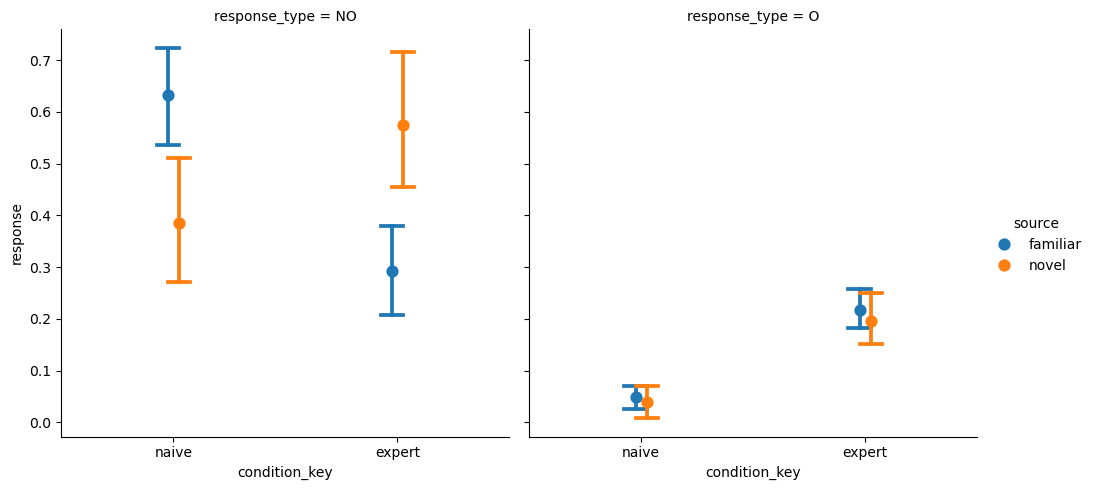

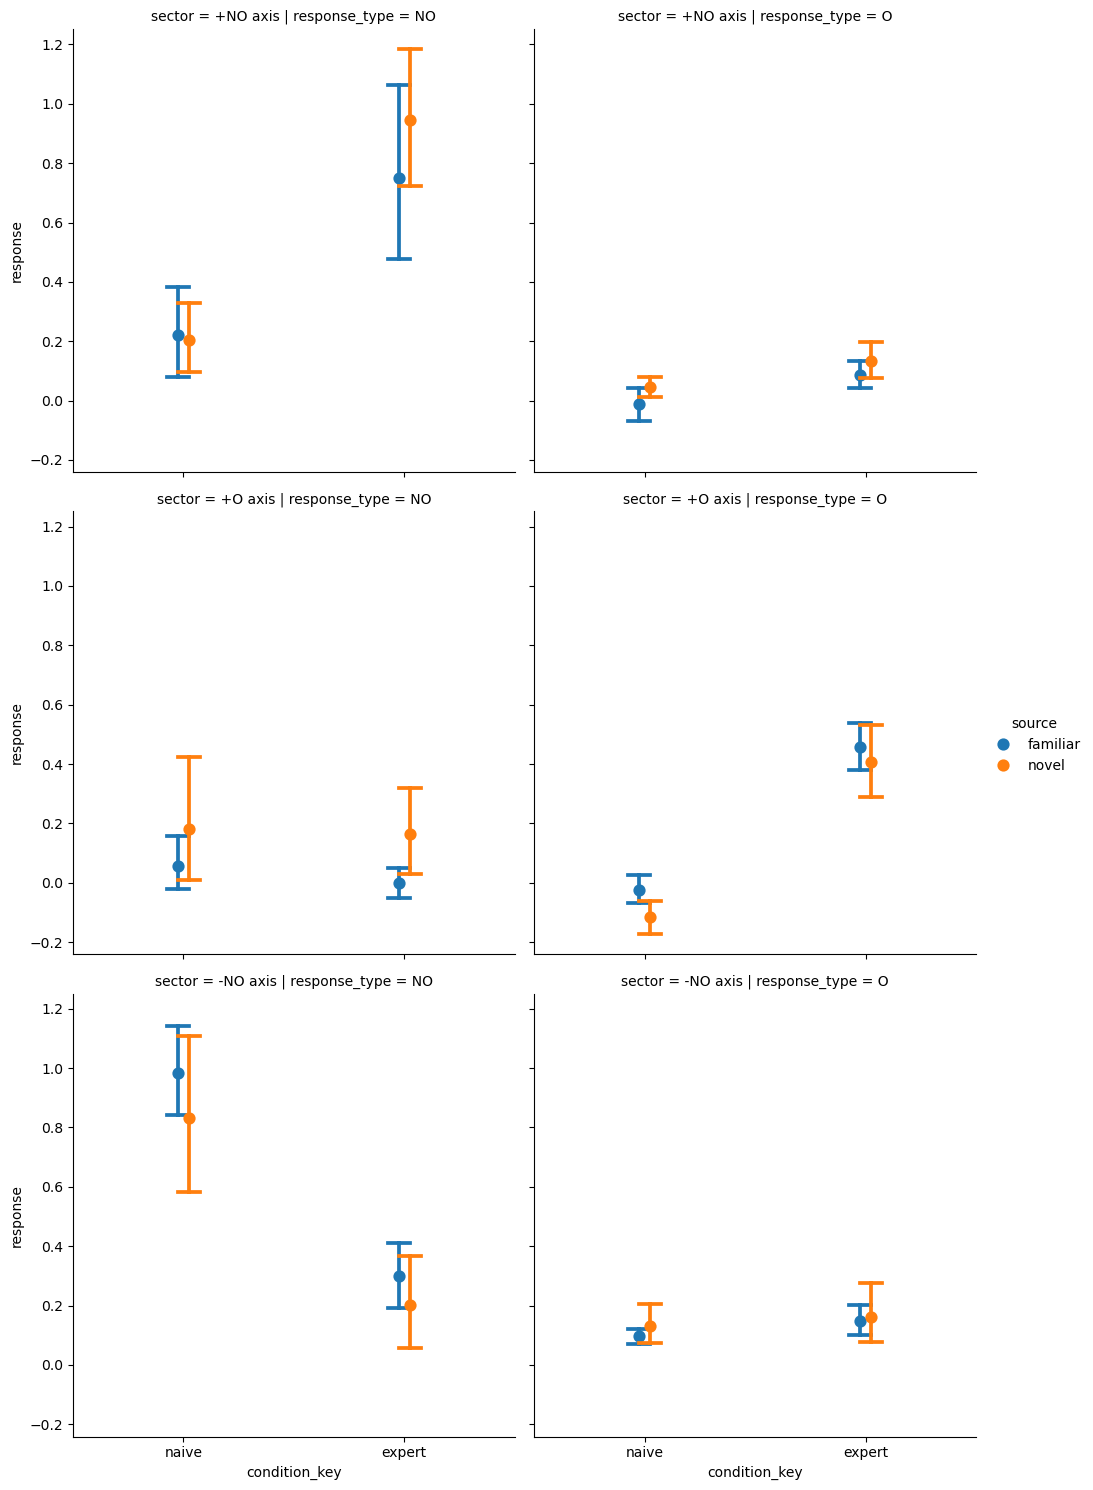

In [4]:
def filter_data(
        table,
        group_keys = ["source", "sector", "condition_key", "response_type", "image_id", "time_seconds"],
        window = (0.2,1.0),
        point_est = False, 
        plot = False):
    traces = table.loc[table.record_type.eq("trace")]
    # Average images within each neuron first (observation_id), then give neurons equal weight.
    neurons = traces.groupby(group_keys + ["observation_id"])["response"].mean().reset_index()
    
    if point_est:
        window = neurons.loc[neurons.time_seconds.between(*window)]
        neurons = window.groupby(["source", "sector", "condition_key", "response_type", "image_id", "observation_id"]).mean().reset_index()
        if plot:
            sns.catplot(neurons, 
                        x = 'condition_key', y = 'response', hue = 'source', 
                        col = 'response_type', 
                        # row = 'sector',
                        order = ['naive', 'expert'],
                        # palette={'NO':'black', 'O':'red'},
                        kind = 'point', linestyle = 'none', capsize = .1, dodge = True, 
                        )
            
            sns.catplot(neurons, 
                        x = 'condition_key', y = 'response', hue = 'source', 
                        col = 'response_type', 
                        row = 'sector',
                        order = ['naive', 'expert'],
                        # palette={'NO':'black', 'O':'red'},
                        kind = 'point', linestyle = 'none', capsize = .1, dodge = True, 
                        )
    
    elif plot:
        sns.relplot(neurons.loc[neurons.condition_key.eq('expert')], 
                    x = 'time_seconds', y = 'response', hue = 'response_type', 
                    col = 'source', row = 'sector',
                    kind = 'line',
                    palette={'NO':'black', 'O':'red'},
                    )

    return neurons


point_data = filter_data(data, point_est=True, plot=True)
point_data
    

,source,sector,condition_key,response_type,image_id,observation_id,time_seconds,response
0,familiar,+NO axis,expert,NO,1.0,1,0.6,7.999223
1,familiar,+NO axis,expert,NO,2.0,1,0.6,0.845371
2,familiar,+NO axis,expert,O,1.0,1,0.6,0.066601
3,familiar,+NO axis,expert,O,2.0,1,0.6,0.218316
4,familiar,+NO axis,expert_no_fb,NO,1.0,1,0.6,2.177282
...,...,...,...,...,...,...,...,...
85,novel,-NO axis,expert_no_fb_no_lat,O,3.0,6,0.6,0.142660
86,novel,-NO axis,expert_no_lat,NO,3.0,6,0.6,1.219425
87,novel,-NO axis,expert_no_lat,O,3.0,6,0.6,0.093176
88,novel,-NO axis,naive,NO,3.0,6,0.6,0.622871


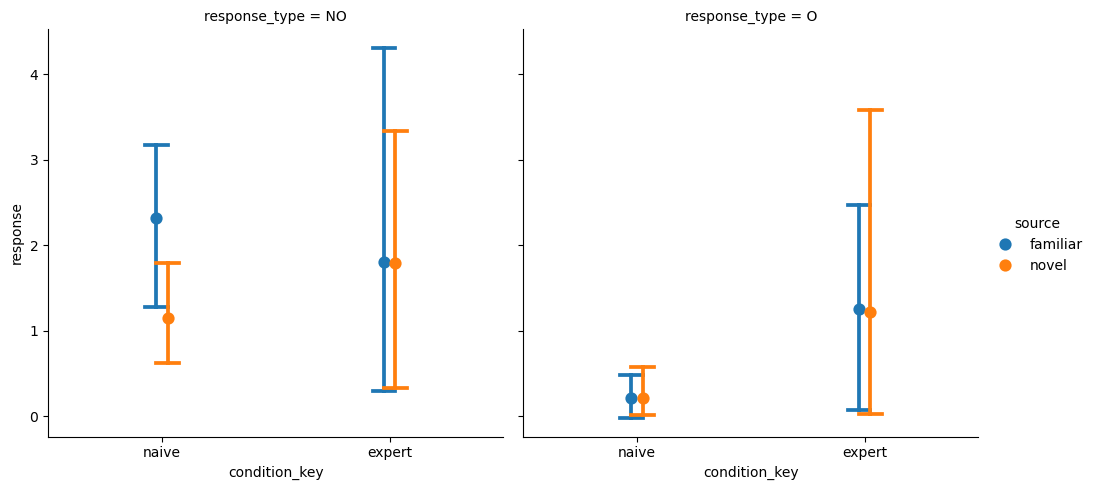

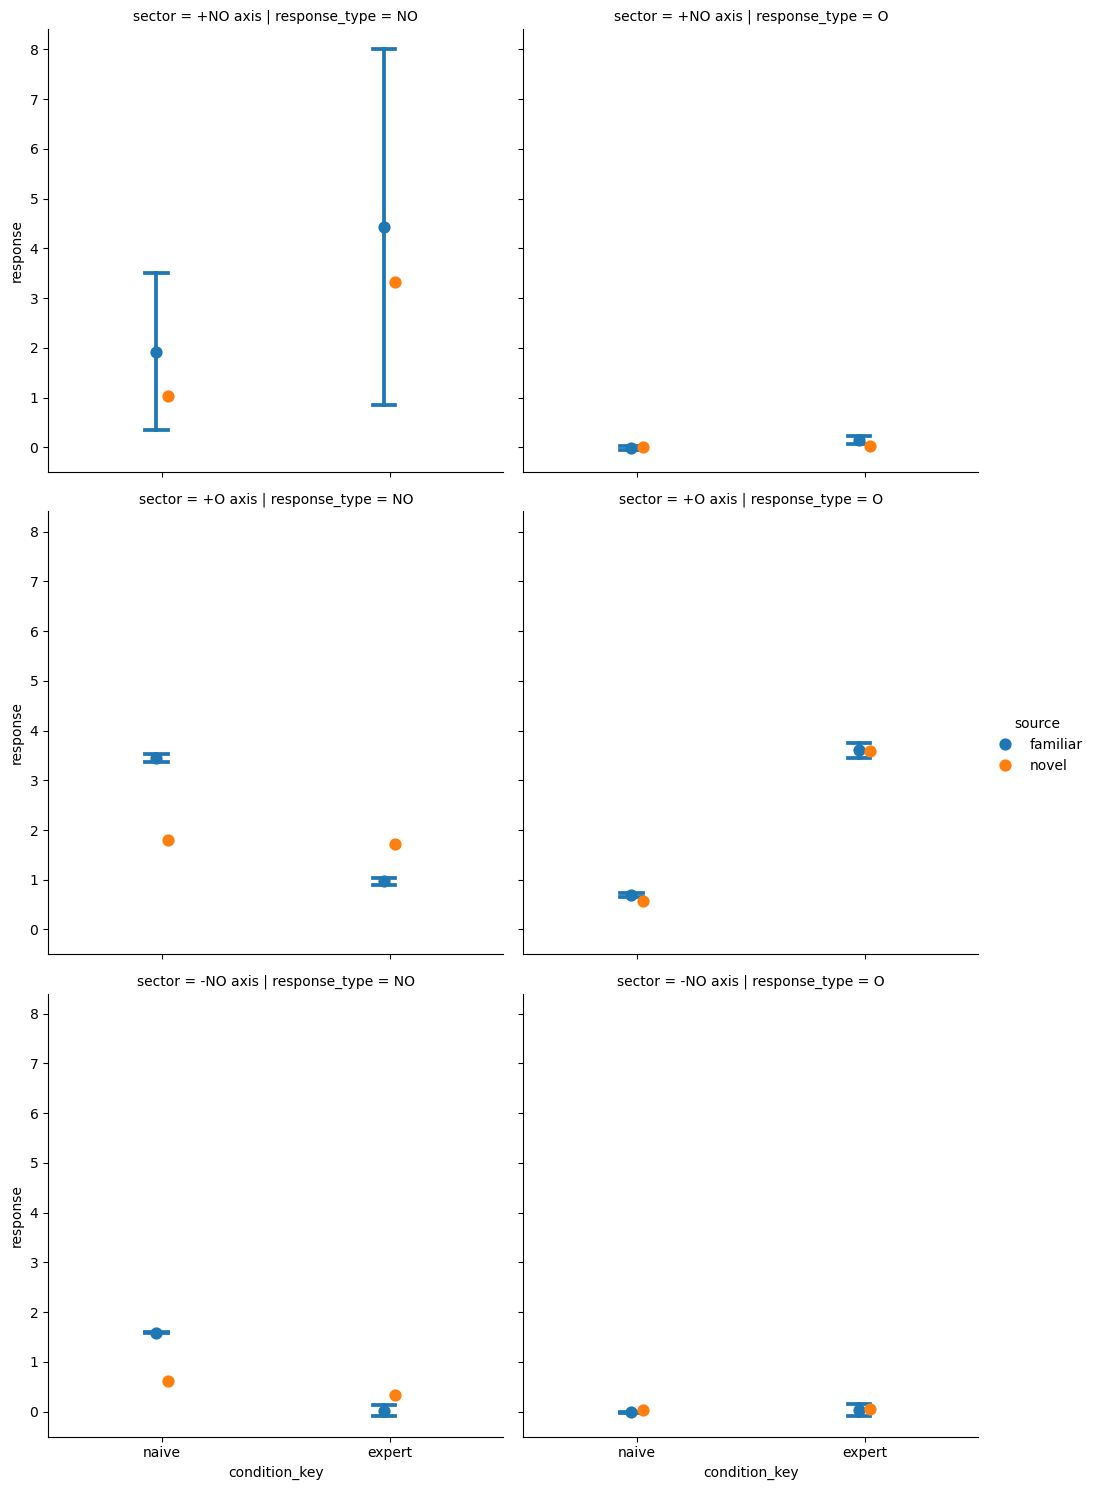

In [5]:
point_model = filter_data(model, point_est=True, plot=True)
point_model


In [6]:
# Lifetime sparseness for each neuron (Vinje & Gallant 2000), per condition x source x response type
def lifetime_sparseness(r, rectify=True):
    """S = (1 - (sum r)^2 / (n * sum r^2)) / (1 - 1/n); 0 = equal response to all images, 1 = responds to one.
    Undefined (NaN) for n < 2 images or all-zero responses."""
    r = np.asarray(r, dtype=float)
    if rectify:
        # Responses are baseline-SD units and can be negative; S is only bounded to [0, 1] for r >= 0.
        r = np.clip(r, 0, None)
    n, sum_sq = r.size, np.sum(r ** 2)
    if n < 2 or sum_sq == 0:
        return np.nan
    return (1 - r.sum() ** 2 / (n * sum_sq)) / (1 - 1 / n)

def add_selectivity(pointdf):
    keys = ["observation_id", "sector", "condition_key", "source", "response_type"]
    sparseness = (pointdf.groupby(keys)["response"]
                .agg(selectivity=lifetime_sparseness, n_images="size")
                .reset_index())

    print(sparseness.groupby(["condition_key", "source"]).n_images.value_counts())

    sel_pointdf = pointdf.merge(sparseness, on=keys, how="left")
    return sel_pointdf


condition_key  source    n_images
expert         familiar  4           182
               novel     2           164
naive          familiar  4           182
               novel     2           164
Name: count, dtype: int64


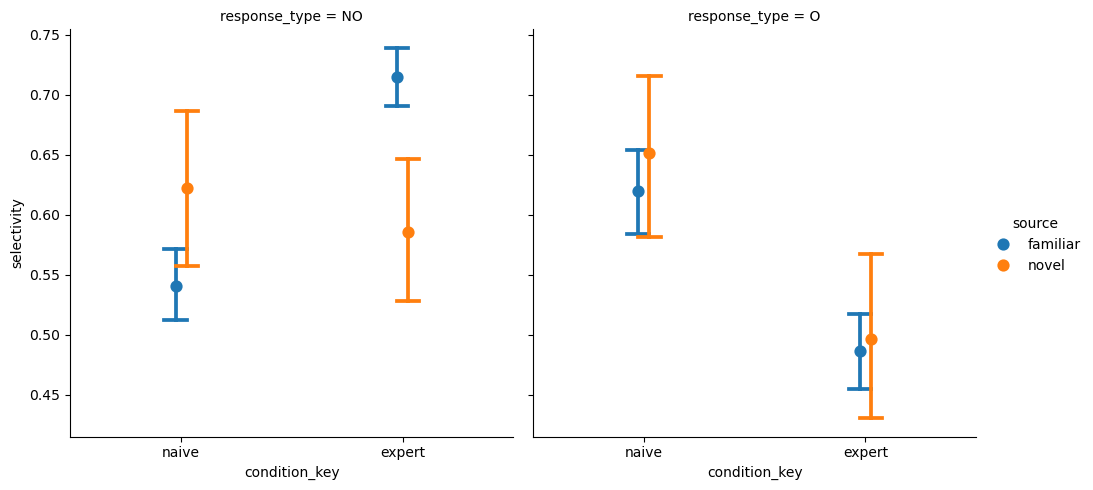

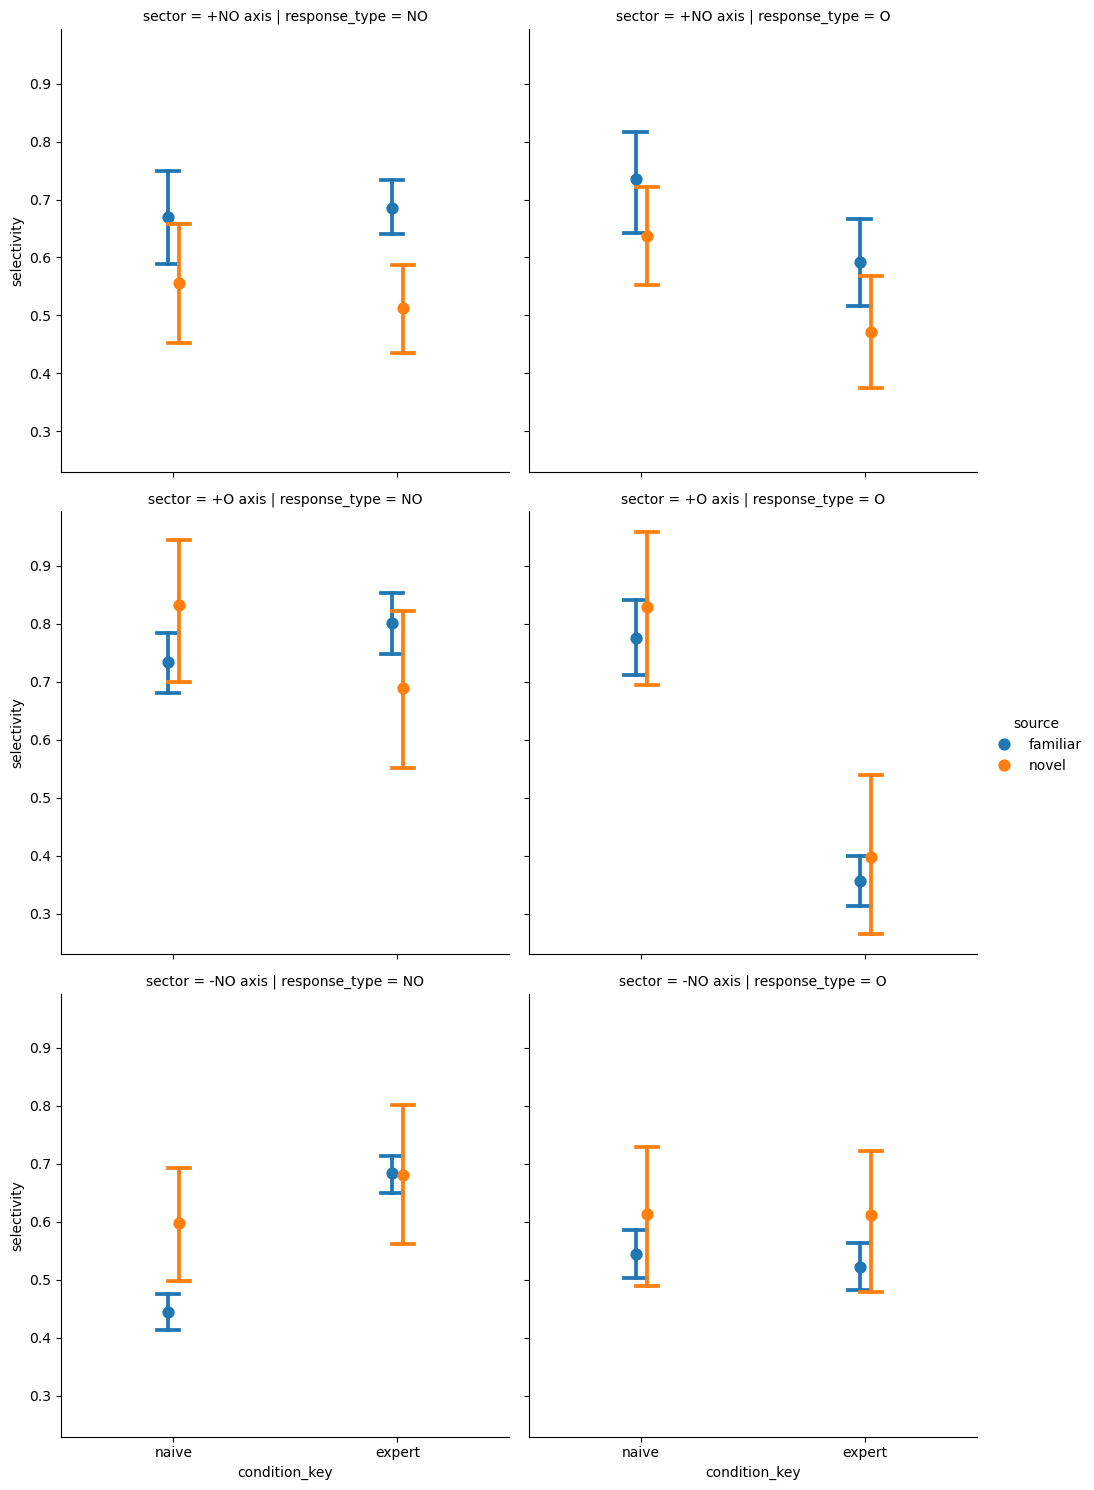

In [7]:
selective_point_data = add_selectivity(point_data)
selective_point_data

sns.catplot(selective_point_data,
            col = 'response_type', order = ['naive', 'expert'],
            x = 'condition_key', hue = 'source', y = 'selectivity', 
            # row = 'sector',
            kind = 'point', capsize = .1, dodge = True, linestyle = 'none')

sns.catplot(selective_point_data,
            col = 'response_type', order = ['naive', 'expert'],
            x = 'condition_key', hue = 'source', y = 'selectivity', 
            row = 'sector',
            kind = 'point', capsize = .1, dodge = True, linestyle = 'none')

condition_key        source    n_images
expert               familiar  2           6
                     novel     1           6
expert_no_fb         familiar  2           6
                     novel     1           6
expert_no_fb_no_lat  familiar  2           6
                     novel     1           6
expert_no_lat        familiar  2           6
                     novel     1           6
naive                familiar  2           6
                     novel     1           6
Name: count, dtype: int64


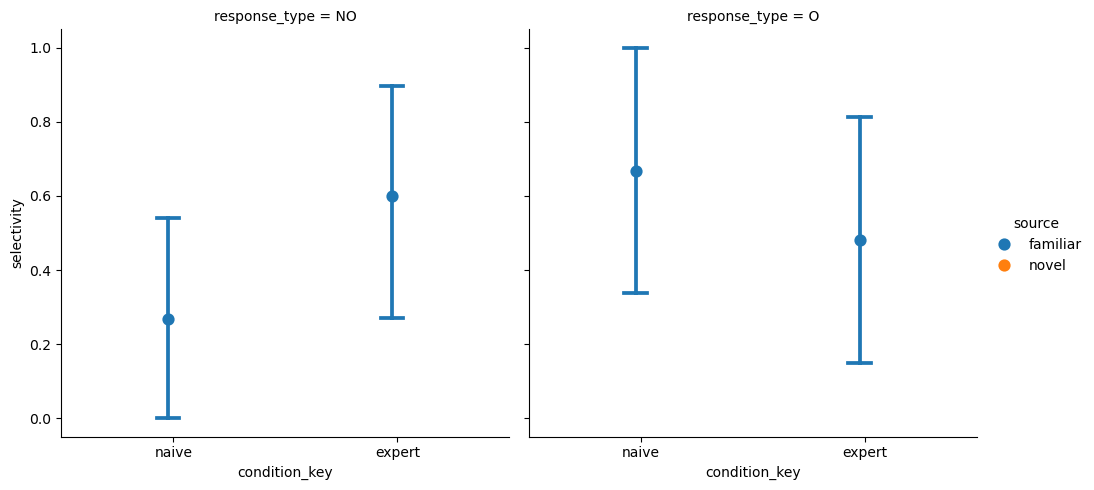

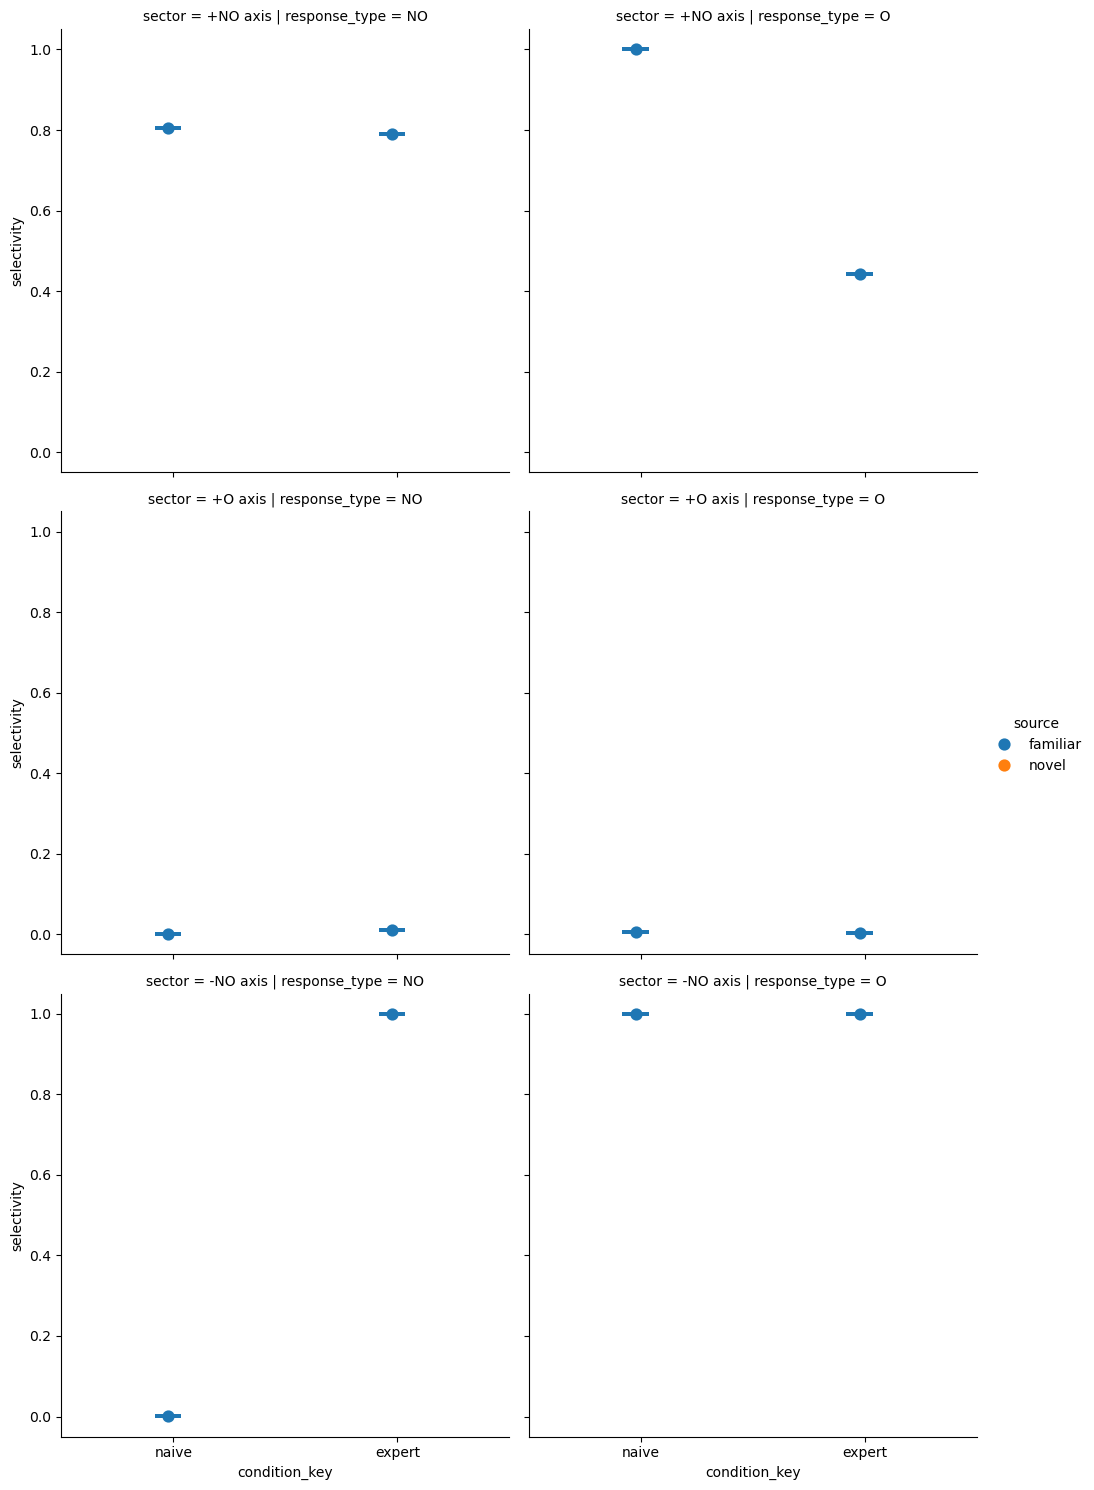

In [8]:
selective_point_model = add_selectivity(point_model)
selective_point_model

sns.catplot(selective_point_model,
            col = 'response_type', order = ['naive', 'expert'],
            x = 'condition_key', hue = 'source', y = 'selectivity', 
            # row = 'sector',
            kind = 'point', capsize = .1, dodge = True, linestyle = 'none')

sns.catplot(selective_point_model,
            col = 'response_type', order = ['naive', 'expert'],
            x = 'condition_key', hue = 'source', y = 'selectivity', 
            row = 'sector',
            kind = 'point', capsize = .1, dodge = True, linestyle = 'none')

# Model plotting code

In [9]:
traces = model.loc[model.record_type.eq("trace")]
keys = ["source", "sector", "condition_key", "response_type", "time_seconds"]
# Average images within each neuron first, then give neurons equal weight.
neurons = traces.groupby(keys + ["observation_id"])["response"].mean()
means = neurons.groupby(keys).mean().reset_index()

group = ["source", "sector", "condition_key", "response_type"]
window = means.loc[means.time_seconds.between(0, 1)]
new_model = window.groupby(group)["response"].mean().reset_index()
new_model

,source,sector,condition_key,response_type,response
0,familiar,+NO axis,expert,NO,4.010264
1,familiar,+NO axis,expert,O,0.122420
2,familiar,+NO axis,expert_no_fb,NO,1.173197
3,familiar,+NO axis,expert_no_fb,O,0.074246
4,familiar,+NO axis,expert_no_fb_no_lat,NO,1.266391
5,familiar,+NO axis,expert_no_fb_no_lat,O,0.136587
6,familiar,+NO axis,expert_no_lat,NO,4.548152
7,familiar,+NO axis,expert_no_lat,O,0.117150
8,familiar,+NO axis,naive,NO,1.747187
9,familiar,+NO axis,naive,O,-0.011251


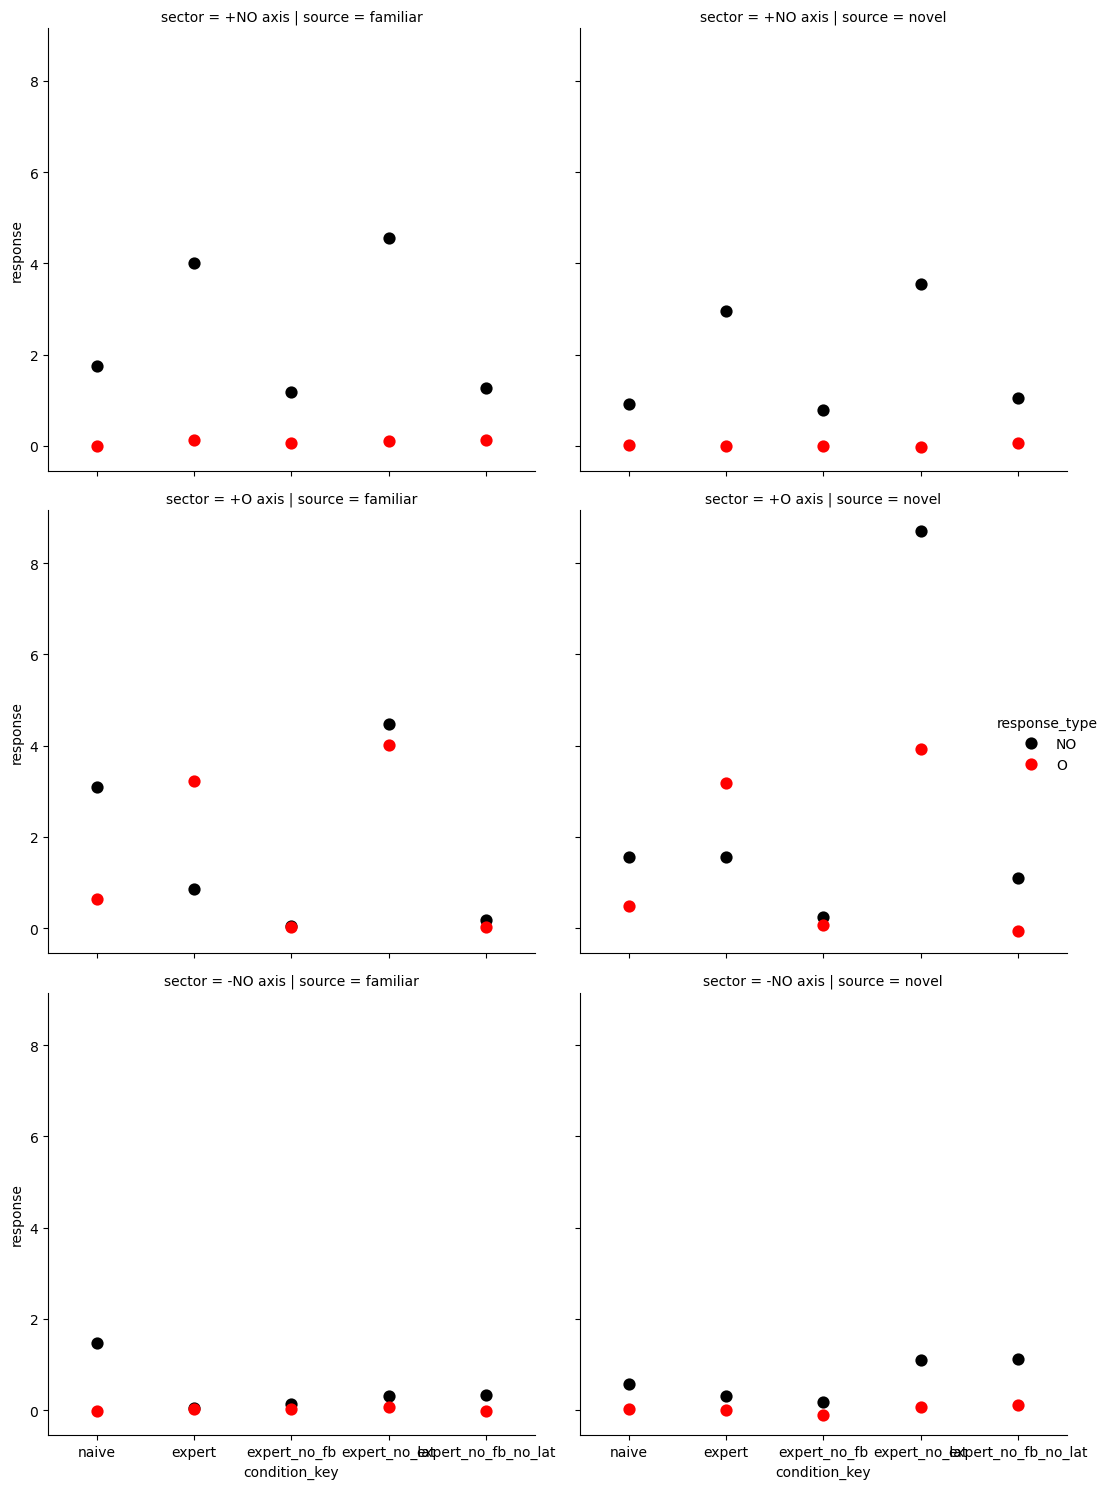

In [12]:
sns.catplot(new_model, row = 'sector', col = 'source',
            x='condition_key', y = 'response', 
            hue = 'response_type', 
            palette={'NO':'black', 'O':'red'}, 
            kind = 'point', linestyle = 'none',
            order=['naive', 'expert', 'expert_no_fb', 'expert_no_lat', 'expert_no_fb_no_lat'])
plt.tight_layout()
plt.show()